# Practicing Using Pandas with Pokemon Dataset

In [1]:
import pandas as pd
import re

import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max.columns", None) # Used to show all columns when printing out df

In [3]:
df = pd.read_csv('pokemon_data.csv')

df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
# See all columns
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk',
       'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [5]:
# See shape of df (n_rows x n_columns)

df.shape

(800, 12)

In [6]:
# Read one column
df['Name']

0                  Bulbasaur
1                    Ivysaur
2                   Venusaur
3      VenusaurMega Venusaur
4                 Charmander
               ...          
795                  Diancie
796      DiancieMega Diancie
797      HoopaHoopa Confined
798       HoopaHoopa Unbound
799                Volcanion
Name: Name, Length: 800, dtype: object

In [8]:
# Reading multiple columns -- note the double []

df[['Name', 'Type 1', 'HP']]

,Name,Type 1,HP
0,Bulbasaur,Grass,45
1,Ivysaur,Grass,60
2,Venusaur,Grass,80
3,VenusaurMega Venusaur,Grass,80
4,Charmander,Fire,39
...,...,...,...
795,Diancie,Rock,50
796,DiancieMega Diancie,Rock,50
797,HoopaHoopa Confined,Psychic,80
798,HoopaHoopa Unbound,Psychic,80


In [9]:
# Read a row with integer location

df.iloc[1]

#                   2
Name          Ivysaur
Type 1          Grass
Type 2         Poison
HP                 60
Attack             62
Defense            63
Sp. Atk            80
Sp. Def            80
Speed              60
Generation          1
Legendary       False
Name: 1, dtype: object

In [10]:
# Read several rows using integer location -- not inclusive of end of range

df.iloc[0:3]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


In [11]:
# Read a specifc location with integer location -> the first dimension refers to rows, the second dimension refers to columns.

df.iloc[2,1]

'Venusaur'

In [13]:
# Read a column with integer location

df.iloc[:, 1]

0                  Bulbasaur
1                    Ivysaur
2                   Venusaur
3      VenusaurMega Venusaur
4                 Charmander
               ...          
795                  Diancie
796      DiancieMega Diancie
797      HoopaHoopa Confined
798       HoopaHoopa Unbound
799                Volcanion
Name: Name, Length: 800, dtype: object

In [14]:
# Read row with location

df.loc[df['Name'] == 'Pikachu']

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
30,25,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False


In [15]:
# Read multiple rows based on condition using location

df.loc[df['Type 1'] == 'Electric']

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
30,25,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False
31,26,Raichu,Electric,NaN,60,90,55,90,80,110,1,False
88,81,Magnemite,Electric,Steel,25,35,70,95,55,45,1,False
89,82,Magneton,Electric,Steel,50,60,95,120,70,70,1,False
108,100,Voltorb,Electric,NaN,40,30,50,55,55,100,1,False
109,101,Electrode,Electric,NaN,60,50,70,80,80,140,1,False
134,125,Electabuzz,Electric,NaN,65,83,57,95,85,105,1,False
146,135,Jolteon,Electric,NaN,65,65,60,110,95,130,1,False
157,145,Zapdos,Electric,Flying,90,90,85,125,90,100,1,True
186,172,Pichu,Electric,NaN,20,40,15,35,35,60,2,False


In [83]:
# Read multiple rows based on OR condition using location

df.loc[(df['Type 1'] == 'Electric') | (df['Type 2'] == 'Electric')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
30,25,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False
31,26,Raichu,Electric,NaN,60,90,55,90,80,110,1,False
88,81,Magnemite,Electric,Steel,25,35,70,95,55,45,1,False
89,82,Magneton,Electric,Steel,50,60,95,120,70,70,1,False
108,100,Voltorb,Electric,NaN,40,30,50,55,55,100,1,False
109,101,Electrode,Electric,NaN,60,50,70,80,80,140,1,False
134,125,Electabuzz,Electric,NaN,65,83,57,95,85,105,1,False
146,135,Jolteon,Electric,NaN,65,65,60,110,95,130,1,False
157,145,Zapdos,Electric,Flying,90,90,85,125,90,100,1,True
184,170,Chinchou,Water,Electric,75,38,38,56,56,67,2,False


In [84]:
# See numerical data descriptions

df.describe()

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [85]:
# Sorting values alphabetically by name

df.sort_values('Name')

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
510,460,Abomasnow,Grass,Ice,90,92,75,92,85,60,4,False
511,460,AbomasnowMega Abomasnow,Grass,Ice,90,132,105,132,105,30,4,False
68,63,Abra,Psychic,NaN,25,20,15,105,55,90,1,False
392,359,Absol,Dark,NaN,65,130,60,75,60,75,3,False
393,359,AbsolMega Absol,Dark,NaN,65,150,60,115,60,115,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...
632,571,Zoroark,Dark,NaN,60,105,60,120,60,105,5,False
631,570,Zorua,Dark,NaN,40,65,40,80,40,65,5,False
46,41,Zubat,Poison,Flying,40,45,35,30,40,55,1,False
695,634,Zweilous,Dark,Dragon,72,85,70,65,70,58,5,False


In [17]:
# Sorting values reverse alphabetically by name

df.sort_values('Name', ascending=False)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
794,718,Zygarde50% Forme,Dragon,Ground,108,100,121,81,95,95,6,True
695,634,Zweilous,Dark,Dragon,72,85,70,65,70,58,5,False
46,41,Zubat,Poison,Flying,40,45,35,30,40,55,1,False
631,570,Zorua,Dark,NaN,40,65,40,80,40,65,5,False
632,571,Zoroark,Dark,NaN,60,105,60,120,60,105,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...
393,359,AbsolMega Absol,Dark,NaN,65,150,60,115,60,115,3,False
392,359,Absol,Dark,NaN,65,130,60,75,60,75,3,False
68,63,Abra,Psychic,NaN,25,20,15,105,55,90,1,False
511,460,AbomasnowMega Abomasnow,Grass,Ice,90,132,105,132,105,30,4,False


In [88]:
# Multiple sort conditions

df.sort_values(['Type 1', 'HP'], ascending=(1,0))

# First it's sorted by the column Type 1, then within each group of Type 1 it will be sorted by HP
# ascending=(1,0) -> sorting order for each column
# 1 = true, sort Type 1 in ascending (A → Z) order
# 0 = false, sort HP in descending (high → low) order

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
520,469,Yanmega,Bug,Flying,86,76,86,116,56,95,4,False
698,637,Volcarona,Bug,Fire,85,60,65,135,105,100,5,False
231,214,Heracross,Bug,Fighting,80,125,75,40,95,85,2,False
232,214,HeracrossMega Heracross,Bug,Fighting,80,185,115,40,105,75,2,False
678,617,Accelgor,Bug,NaN,80,70,40,100,60,145,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...
106,98,Krabby,Water,NaN,30,105,90,25,25,50,1,False
125,116,Horsea,Water,NaN,30,40,70,70,25,60,1,False
129,120,Staryu,Water,NaN,30,45,55,70,55,85,1,False
139,129,Magikarp,Water,NaN,20,10,55,15,20,80,1,False


In [89]:
# Adding a new column numerical column

df['Total'] = df['Attack'] + df['Defense']

df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,98
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,125
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,165
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,223
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,95


In [90]:
# Adding a new string column

df['Types'] = (df['Type 1'] + " + " + df['Type 2'])

df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total,Types
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,98,Grass + Poison
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,125,Grass + Poison
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,165,Grass + Poison
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,223,Grass + Poison
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,95,NaN


In [91]:
# Dropping a column

df = df.drop(columns=['Total'])

df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN


In [93]:
# Creating new column for total using integer location and sum function

df['Total'] = df.iloc[:, 4:10].sum(axis=1) # from 4th column, until 10th (exclusive)

df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN,309


In [94]:
# Save to CSV

df.to_csv('pokemon_modified.csv', index=False)

In [95]:
# Filtering based on AND condition using location

df.loc[(df['Type 1'] == 'Grass') & (df['Type 2'] == 'Poison')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625
48,43,Oddish,Grass,Poison,45,50,55,75,65,30,1,False,Grass + Poison,320
49,44,Gloom,Grass,Poison,60,65,70,85,75,40,1,False,Grass + Poison,395
50,45,Vileplume,Grass,Poison,75,80,85,110,90,50,1,False,Grass + Poison,490
75,69,Bellsprout,Grass,Poison,50,75,35,70,30,40,1,False,Grass + Poison,300
76,70,Weepinbell,Grass,Poison,65,90,50,85,45,55,1,False,Grass + Poison,390
77,71,Victreebel,Grass,Poison,80,105,65,100,70,70,1,False,Grass + Poison,490


In [25]:
# Filtering based on AND condition from two columns using locator and then sorting by HP value high to low

df.loc[(df['Type 1'] == 'Fire') & (df['HP'] >= 70)].sort_values('HP', ascending = False)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
263,244,Entei,Fire,NaN,115,115,85,90,75,100,2,True,NaN,580
559,500,Emboar,Fire,Fighting,110,123,65,100,65,65,5,False,Fire + Fighting,528
270,250,Ho-oh,Fire,Flying,106,130,90,110,154,90,2,True,Fire + Flying,680
615,555,DarmanitanStandard Mode,Fire,NaN,105,140,55,30,55,95,5,False,NaN,480
616,555,DarmanitanZen Mode,Fire,Psychic,105,30,105,140,105,55,5,False,Fire + Psychic,540
542,485,Heatran,Fire,Steel,91,90,106,130,106,77,4,True,Fire + Steel,600
64,59,Arcanine,Fire,NaN,90,110,80,100,80,95,1,False,NaN,555
558,499,Pignite,Fire,Fighting,90,93,55,70,55,55,5,False,Fire + Fighting,418
158,146,Moltres,Fire,Flying,90,100,90,125,85,90,1,True,Fire + Flying,580
736,668,Pyroar,Fire,Normal,86,68,72,109,66,106,6,False,Fire + Normal,507


In [96]:
# Showing all records that contain part of a word or name

df.loc[df['Name'].str.contains('Mega')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625
7,6,CharizardMega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False,Fire + Dragon,634
8,6,CharizardMega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False,Fire + Flying,634
12,9,BlastoiseMega Blastoise,Water,NaN,79,103,120,135,115,78,1,False,NaN,630
19,15,BeedrillMega Beedrill,Bug,Poison,65,150,40,15,80,145,1,False,Bug + Poison,495
23,18,PidgeotMega Pidgeot,Normal,Flying,83,80,80,135,80,121,1,False,Normal + Flying,579
71,65,AlakazamMega Alakazam,Psychic,NaN,55,50,65,175,95,150,1,False,NaN,590
87,80,SlowbroMega Slowbro,Water,Psychic,95,75,180,130,80,30,1,False,Water + Psychic,590
102,94,GengarMega Gengar,Ghost,Poison,60,65,80,170,95,130,1,False,Ghost + Poison,600
124,115,KangaskhanMega Kangaskhan,Normal,NaN,105,125,100,60,100,100,1,False,NaN,590


In [97]:
# Showing all records that do contain part of a word or name

df.loc[df['Name'].str.contains('chu')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
30,25,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False,NaN,320
31,26,Raichu,Electric,NaN,60,90,55,90,80,110,1,False,NaN,485
186,172,Pichu,Electric,NaN,20,40,15,35,35,60,2,False,NaN,205
257,238,Smoochum,Ice,Psychic,45,30,15,85,65,65,2,False,Ice + Psychic,305


In [98]:
# Showing all records that don't contain part of a word or name

df.loc[~df['Name'].str.contains('Mega')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN,309
5,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False,NaN,405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,718,Zygarde50% Forme,Dragon,Ground,108,100,121,81,95,95,6,True,Dragon + Ground,600
795,719,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True,Rock + Fairy,600
797,720,HoopaHoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True,Psychic + Ghost,600
798,720,HoopaHoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True,Psychic + Dark,680


In [99]:
# Filtering out using string contains and an or operator. Note: flags = re.I ignores case!

df.loc[df['Type 1'].str.contains('fire|grass', flags = re.I)]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN,309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,667,Litleo,Fire,Normal,62,50,58,73,54,72,6,False,Fire + Normal,369
736,668,Pyroar,Fire,Normal,86,68,72,109,66,106,6,False,Fire + Normal,507
740,672,Skiddo,Grass,NaN,66,65,48,62,57,52,6,False,NaN,350
741,673,Gogoat,Grass,NaN,123,100,62,97,81,68,6,False,NaN,531


In [102]:
df.loc[df['Type 1'].str.contains('Fire|Grass')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN,309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,667,Litleo,Fire,Normal,62,50,58,73,54,72,6,False,Fire + Normal,369
736,668,Pyroar,Fire,Normal,86,68,72,109,66,106,6,False,Fire + Normal,507
740,672,Skiddo,Grass,NaN,66,65,48,62,57,52,6,False,NaN,350
741,673,Gogoat,Grass,NaN,123,100,62,97,81,68,6,False,NaN,531


In [103]:
# Finding all names that start with "pi"

df.loc[df['Name'].str.startswith('Pi')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
20,16,Pidgey,Normal,Flying,40,45,40,35,35,56,1,False,Normal + Flying,251
21,17,Pidgeotto,Normal,Flying,63,60,55,50,50,71,1,False,Normal + Flying,349
22,18,Pidgeot,Normal,Flying,83,80,75,70,70,101,1,False,Normal + Flying,479
23,18,PidgeotMega Pidgeot,Normal,Flying,83,80,80,135,80,121,1,False,Normal + Flying,579
30,25,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False,NaN,320
136,127,Pinsir,Bug,NaN,65,125,100,55,70,85,1,False,NaN,500
137,127,PinsirMega Pinsir,Bug,Flying,65,155,120,65,90,105,1,False,Bug + Flying,600
186,172,Pichu,Electric,NaN,20,40,15,35,35,60,2,False,NaN,205
219,204,Pineco,Bug,NaN,50,65,90,35,35,15,2,False,NaN,290
239,221,Piloswine,Ice,Ground,100,100,80,60,60,50,2,False,Ice + Ground,450


In [104]:
# Getting all names that end with "saur"

df.loc[df['Name'].str.endswith('saur')]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,Grass + Poison,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,Grass + Poison,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,Grass + Poison,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,Grass + Poison,625


In [105]:
# Conditional change

df.loc[df['Type 1'] == 'Fire', 'Type 1'] = 'Flame'

df.loc[df['Type 1']  == 'Flame']

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
4,4,Charmander,Flame,NaN,39,52,43,60,50,65,1,False,NaN,309
5,5,Charmeleon,Flame,NaN,58,64,58,80,65,80,1,False,NaN,405
6,6,Charizard,Flame,Flying,78,84,78,109,85,100,1,False,Fire + Flying,534
7,6,CharizardMega Charizard X,Flame,Dragon,78,130,111,130,85,100,1,False,Fire + Dragon,634
8,6,CharizardMega Charizard Y,Flame,Flying,78,104,78,159,115,100,1,False,Fire + Flying,634
42,37,Vulpix,Flame,NaN,38,41,40,50,65,65,1,False,NaN,299
43,38,Ninetales,Flame,NaN,73,76,75,81,100,100,1,False,NaN,505
63,58,Growlithe,Flame,NaN,55,70,45,70,50,60,1,False,NaN,350
64,59,Arcanine,Flame,NaN,90,110,80,100,80,95,1,False,NaN,555
83,77,Ponyta,Flame,NaN,50,85,55,65,65,90,1,False,NaN,410


In [108]:
# Changing back because...it's just wrong to rename the types

df.loc[df['Type 1'] == 'Flame', 'Type 1'] = 'Fire'

df.loc[df['Type 1']  == 'Fire']

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Total
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,NaN,309
5,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False,NaN,405
6,6,Charizard,Fire,Flying,78,84,78,109,85,100,1,False,Fire + Flying,534
7,6,CharizardMega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False,Fire + Dragon,634
8,6,CharizardMega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False,Fire + Flying,634
42,37,Vulpix,Fire,NaN,38,41,40,50,65,65,1,False,NaN,299
43,38,Ninetales,Fire,NaN,73,76,75,81,100,100,1,False,NaN,505
63,58,Growlithe,Fire,NaN,55,70,45,70,50,60,1,False,NaN,350
64,59,Arcanine,Fire,NaN,90,110,80,100,80,95,1,False,NaN,555
83,77,Ponyta,Fire,NaN,50,85,55,65,65,90,1,False,NaN,410


In [109]:
# Count Pokemon by generation

df.groupby('Generation').size()

Generation
1    166
2    106
3    160
4    121
5    165
6     82
dtype: int64

In [110]:
df['Generation'].value_counts().sort_index()

Generation
1    166
2    106
3    160
4    121
5    165
6     82
Name: count, dtype: int64

In [111]:
# How many of each type of Pokemon there are in our data

df.groupby('Type 1').size().sort_values(ascending = False)

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Dragon       32
Ghost        32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
dtype: int64

In [112]:
# Average stats by Pokemon type

df.groupby('Type 1')[['HP', 'Attack', 'Defense', 'Speed']].mean()

,HP,Attack,Defense,Speed
Type 1,,,,
Bug,56.884058,70.971014,70.724638,61.681159
Dark,66.806452,88.387097,70.225806,76.161290
Dragon,83.312500,112.125000,86.375000,83.031250
Electric,59.795455,69.090909,66.295455,84.500000
Fairy,74.117647,61.529412,65.705882,48.588235
Fighting,69.851852,96.777778,65.925926,66.074074
Fire,69.903846,84.769231,67.769231,74.442308
Flying,70.750000,78.750000,66.250000,102.500000
Ghost,64.437500,73.781250,81.187500,64.343750


In [113]:
# Max speed Pokéemon by type

df.groupby('Type 1')['Speed'].max().sort_values(ascending = False)

Type 1
Psychic     180
Bug         160
Rock        150
Grass       145
Electric    140
Normal      135
Ghost       130
Poison      130
Fire        126
Dark        125
Flying      123
Water       122
Dragon      120
Ground      120
Fighting    118
Ice         110
Steel       110
Fairy        99
Name: Speed, dtype: int64

In [115]:
# Legendary Pokemon proportion by generation --> works because "Legendary" is True/False for each

df.groupby('Generation')['Legendary'].mean()

Generation
1    0.036145
2    0.047170
3    0.112500
4    0.107438
5    0.090909
6    0.097561
Name: Legendary, dtype: float64

# Plots

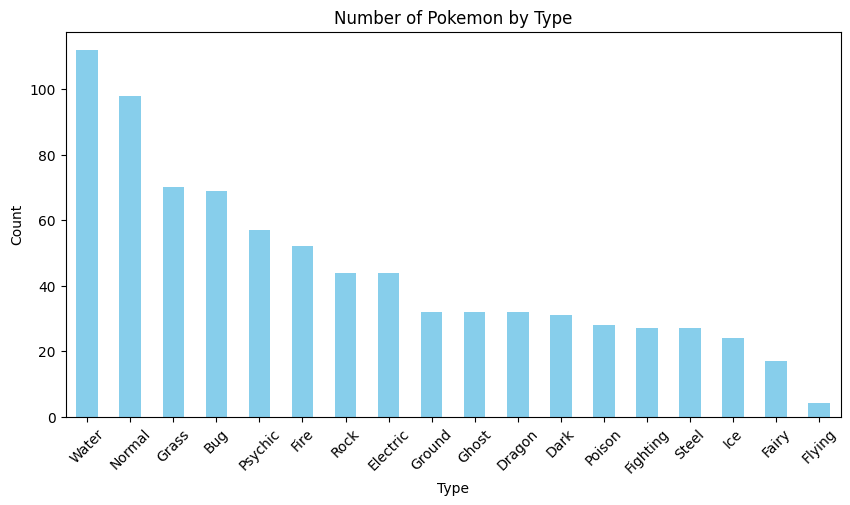

In [17]:
# Bar Chart: Number of Pokemon by type

type_counts = df['Type 1'].value_counts()
type_counts.plot(kind='bar', figsize=(10, 5), color='skyblue')

plt.title('Number of Pokemon by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [18]:
type_counts

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

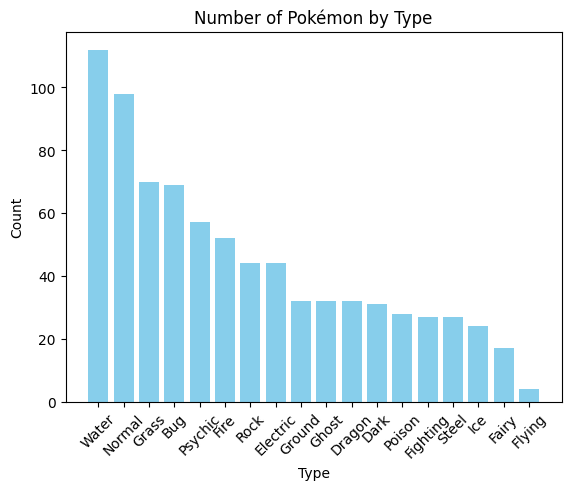

In [41]:
plt.bar(type_counts.index, type_counts.values, color='skyblue')

plt.title('Number of Pokemon by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

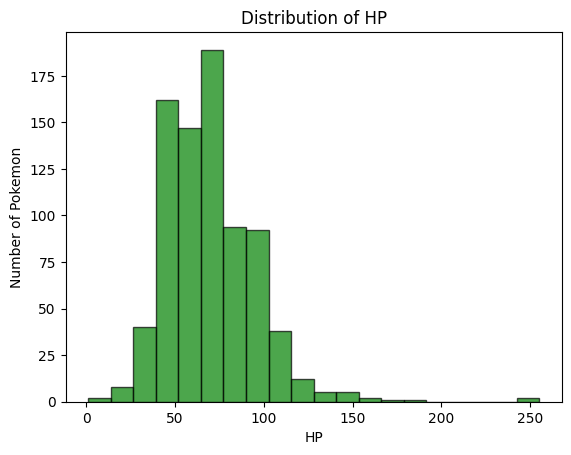

In [42]:
# Histogram: HP distribution

df['HP'].plot(kind='hist', bins=20, color='green', edgecolor='black', alpha=0.7)

plt.title('Distribution of HP')
plt.xlabel('HP')
plt.ylabel('Number of Pokemon')

plt.show()

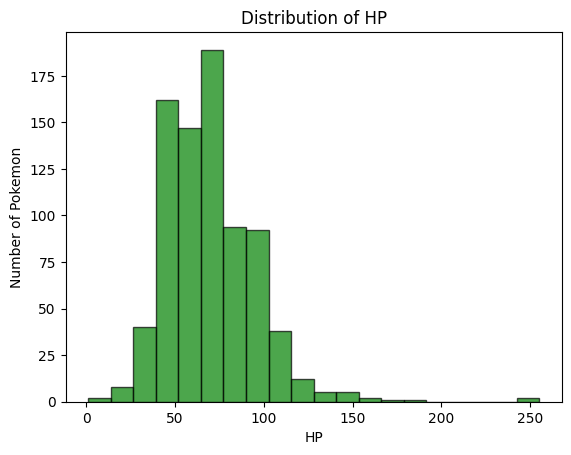

In [131]:
plt.hist(df['HP'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution of HP')
plt.xlabel('HP')
plt.ylabel('Number of Pokemon')
plt.show()

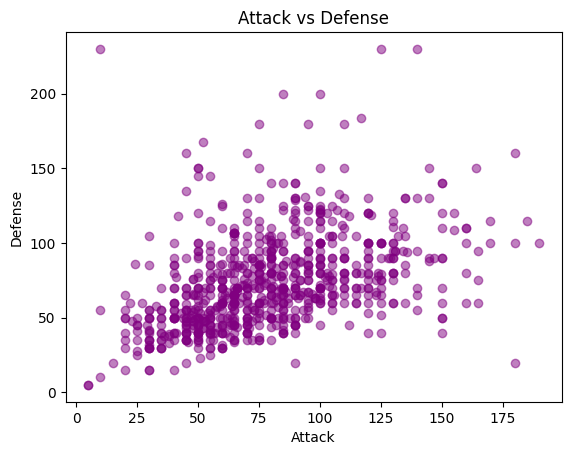

In [44]:
# Scatter Plot: Attack vs Defense

plt.scatter(df['Attack'], df['Defense'], alpha=0.5, color='purple')

plt.title('Attack vs Defense')
plt.xlabel('Attack')
plt.ylabel('Defense')

plt.show()

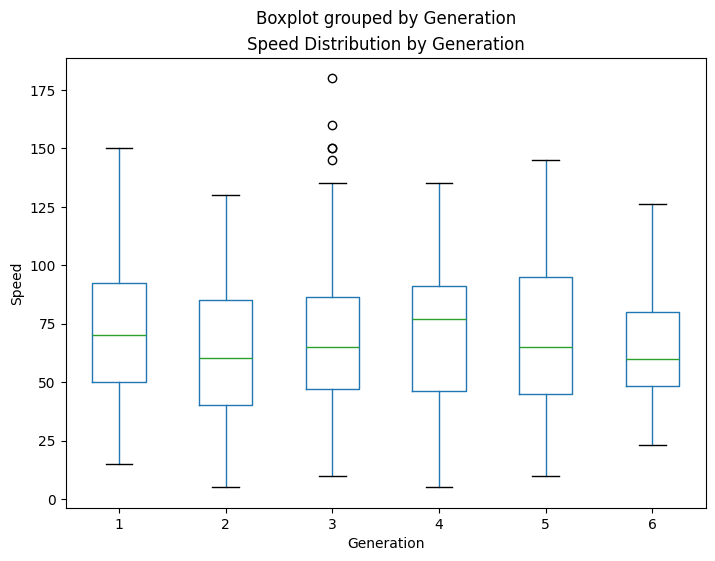

In [119]:
# Box Plot: Speed by Generation

df.boxplot(column='Speed', by='Generation', grid=False, figsize=(8, 6))
plt.title('Speed Distribution by Generation')
#plt.suptitle('')
plt.xlabel('Generation')
plt.ylabel('Speed')
plt.show()

- Box: The Interquartile Range (IQR) is the range between the first quartile (Q1, 25th percentile) and the third quartile (Q3, 75th percentile) --> Line: Median

- The whiskers extend from the box to the smallest and largest values in the dataset, but they do not extend beyond a certain threshold. The whiskers are typically defined as:
    - The minimum value within 1.5 * IQR below Q1.  
    - The maximum value within 1.5 * IQR above Q3.

- Outliers: Any data points outside of these whiskers (beyond 1.5 * IQR from Q1 or Q3) are considered outliers and are usually plotted as individual points outside the whiskers.

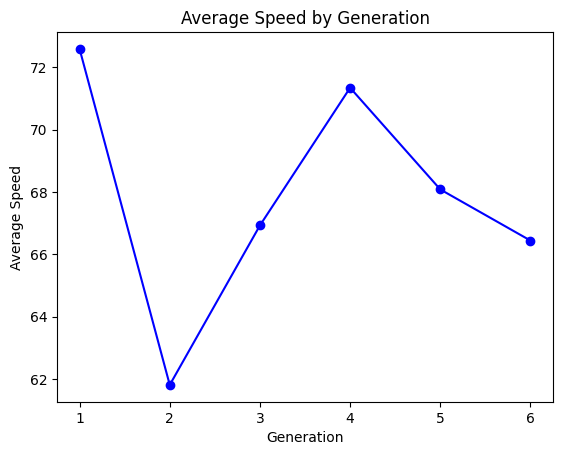

In [120]:
# Line Plot: Average Speed by Generation

avg_speed = df.groupby('Generation')['Speed'].mean()
avg_speed.plot(kind='line', marker='o', color='blue')

plt.title('Average Speed by Generation')
plt.xlabel('Generation')
plt.ylabel('Average Speed')

plt.show()

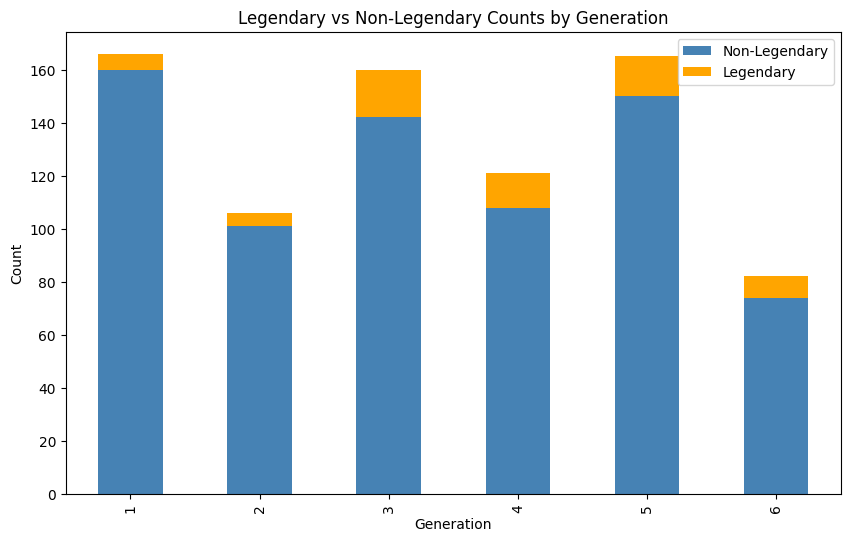

In [121]:
# Stacked Bar Chart: Legendary vs Non-Legendary counts by Generation

gen_legendary_counts = df.groupby(['Generation', 'Legendary']).size().unstack()
gen_legendary_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['steelblue', 'orange'])

plt.title('Legendary vs Non-Legendary Counts by Generation')
plt.xlabel('Generation')
plt.ylabel('Count')
plt.legend(['Non-Legendary', 'Legendary'])

plt.show()

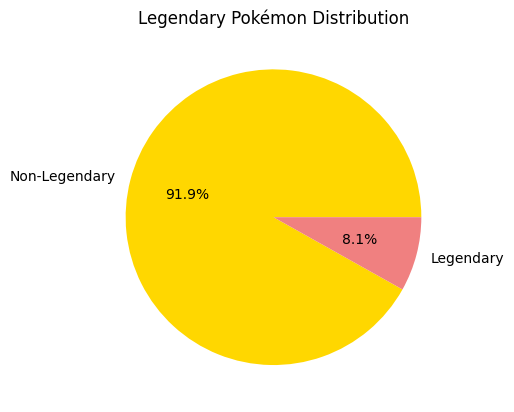

In [122]:
# DO NOT use pie charts
# Pie Chart: Distribution of Legendary Pokémon

legendary_counts = df['Legendary'].value_counts()
plt.pie(legendary_counts, labels=['Non-Legendary', 'Legendary'], autopct='%1.1f%%', colors=['gold', 'lightcoral']) #autopct used for showing percentages

plt.title('Legendary Pokémon Distribution')
plt.ylabel('')
plt.show()

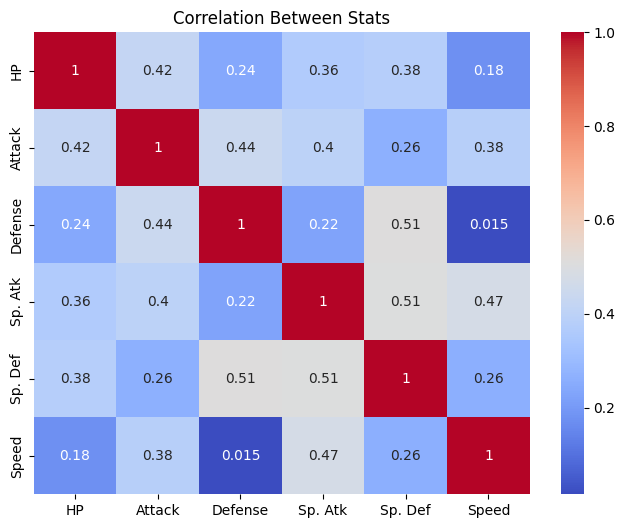

In [124]:
# Heatmap: Correlation Between Stats

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].corr(), annot=True, cmap='coolwarm') # df.corr() by default calculates the Pearson correlation coefficient

plt.title('Correlation Between Stats')
plt.show()

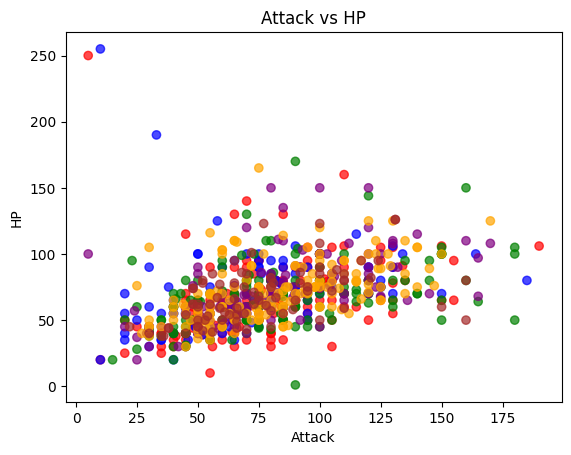

In [125]:
# Scatter Plot: Attack vs HP with Generation Colors

colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'purple', 5: 'orange', 6: 'brown'}

plt.scatter(df['Attack'], df['HP'], c=df['Generation'].map(colors), alpha=0.7)

plt.title('Attack vs HP')
plt.xlabel('Attack')
plt.ylabel('HP')
plt.show()

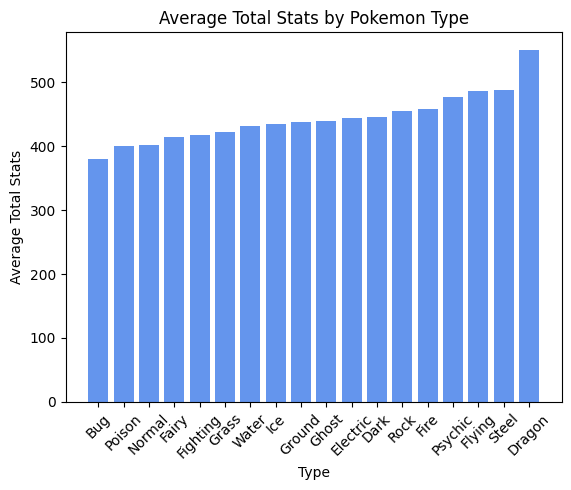

In [126]:
# Total Stats Distribution by Pokemon Type

avg_total_stats = df.groupby('Type 1')['Total'].mean().sort_values()

plt.bar(avg_total_stats.index, avg_total_stats.values, color='cornflowerblue')

plt.title('Average Total Stats by Pokemon Type')
plt.xlabel('Type')
plt.ylabel('Average Total Stats')
plt.xticks(rotation=45)

plt.show()


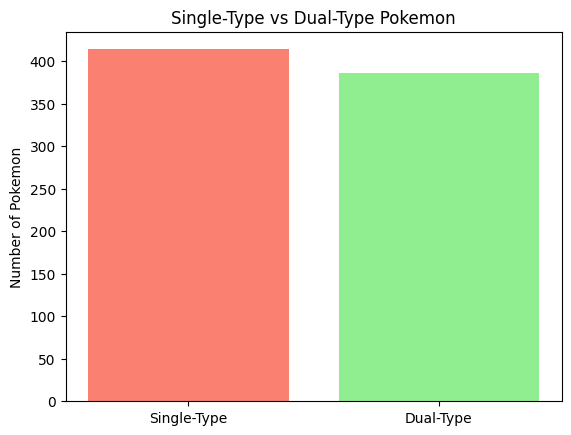

In [127]:
# Number of Dual-Type Pokemon vs Single-Type Pokémon

dual_type_counts = df['Type 2'].notnull().value_counts()

plt.bar(['Single-Type', 'Dual-Type'], dual_type_counts.values, color=['salmon', 'lightgreen'])

plt.title('Single-Type vs Dual-Type Pokemon')
plt.ylabel('Number of Pokemon')

plt.show()


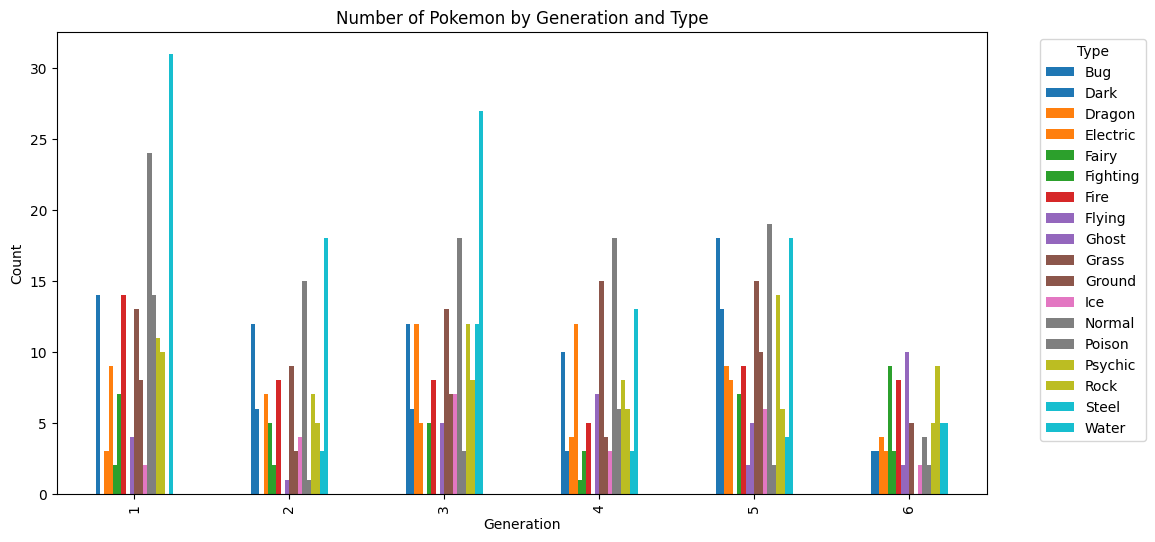

In [128]:
# Pokemon Count per Generation and Type

gen_type_counts = df.groupby(['Generation', 'Type 1']).size().unstack()

gen_type_counts.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='tab10')

plt.title('Number of Pokemon by Generation and Type')
plt.xlabel('Generation')
plt.ylabel('Count')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [129]:
df.groupby(['Generation', 'Type 1']).size()

Generation  Type 1  
1           Bug         14
            Dragon       3
            Electric     9
            Fairy        2
            Fighting     7
                        ..
6           Poison       2
            Psychic      5
            Rock         9
            Steel        5
            Water        5
Length: 98, dtype: int64

In [130]:
df.groupby(['Generation', 'Type 1']).size().unstack()

Type 1,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Generation,,,,,,,,,,,,,,,,,,
1,14.0,NaN,3.0,9.0,2.0,7.0,14.0,NaN,4.0,13.0,8.0,2.0,24.0,14.0,11.0,10.0,NaN,31.0
2,12.0,6.0,NaN,7.0,5.0,2.0,8.0,NaN,1.0,9.0,3.0,4.0,15.0,1.0,7.0,5.0,3.0,18.0
3,12.0,6.0,12.0,5.0,NaN,5.0,8.0,NaN,5.0,13.0,7.0,7.0,18.0,3.0,12.0,8.0,12.0,27.0
4,10.0,3.0,4.0,12.0,1.0,3.0,5.0,NaN,7.0,15.0,4.0,3.0,18.0,6.0,8.0,6.0,3.0,13.0
5,18.0,13.0,9.0,8.0,NaN,7.0,9.0,2.0,5.0,15.0,10.0,6.0,19.0,2.0,14.0,6.0,4.0,18.0
6,3.0,3.0,4.0,3.0,9.0,3.0,8.0,2.0,10.0,5.0,NaN,2.0,4.0,2.0,5.0,9.0,5.0,5.0
